# Aula 6 - Imputação e Normalização de Dados

## Motivação

Na Aula 5, usamos assimetria, curtose e valores atípicos para
**descrever** distribuições. O valor dos pedidos, por exemplo,
apresentava uma cauda longa à direita, e um grupo pequeno de clientes
atacadistas elevava a média. Essa análise caracterizava os dados
observados, mas ainda não envolvia qualquer modificação da base.

Nesta aula, o diagnóstico passa a orientar **decisões de tratamento**.
Antes de ajustar um modelo, construir um indicador ou comparar grupos,
uma base real geralmente exige algum preparo. Esse conjunto de operações
recebe o nome de pré-processamento. As escolhas feitas nessa etapa
alteram os dados que chegam às análises posteriores e, portanto, afetam
as estimativas e conclusões produzidas a partir deles.

Para ilustrar, usaremos a base de anúncios de aluguel em São Paulo da
atividade prática. Ela reúne três problemas que aparecem com frequência
em dados reais:

-   **lacunas** em algumas colunas, que podem representar perda de
    informação ou ausência estrutural,
-   variáveis medidas em **unidades diferentes**, como área em m²,
    aluguel em reais e número de quartos,
-   Distribuições com **cauda longa**, em que poucos imóveis muito caros
    esticam a escala.

Cada problema pede uma decisão diferente. A **imputação** estima valores
que não foram observados. O **escalonamento** coloca variáveis em
escalas numéricas comparáveis. As **transformações não lineares**
modificam a geometria da distribuição e podem reduzir sua assimetria. O
termo *normalização* aparece na literatura com significados diferentes,
por isso o roteiro distingue explicitamente escalonamento de
transformação. Nenhum desses tratamentos é neutro. Imputar introduz
valores estimados, escalonar muda a unidade de representação e
transformar altera as distâncias entre as observações. Avaliaremos cada
técnica tanto pelo problema que resolve quanto pelas mudanças que
produz.

> **O que cada tratamento muda nos dados?**

## Objetivos de aprendizagem

Ao final deste roteiro, você será capaz de:

1.  Distinguir ausência estrutural de ausência por falha de registro.
2.  Imputar valores pela média, mediana, moda e mediana por grupo, além
    de medir o erro de cada estratégia.
3.  Escalonar variáveis com `StandardScaler`, `RobustScaler` e
    `MinMaxScaler`, reconhecendo a sensibilidade de cada um a extremos.
4.  Reduzir a assimetria com `log`, `log1p`, Box-Cox e Yeo-Johnson.
5.  Explicar a diferença entre mudar a **régua** (escalonar) e mudar a
    **forma** (transformar) de uma distribuição.

> **Como usar este roteiro**
>
> O roteiro usa a base `imoveis_sao_paulo.csv`, a mesma da atividade
> prática, salva em `imoveis-sao-paulo/data/`.
>
> Além das bibliotecas da Aula 5, usamos o módulo
> `sklearn.preprocessing` do **scikit-learn**.
>
> Ao final, três perguntas ajudam a consolidar as escolhas de
> tratamento.

# 1. Preparando a base

Começamos importando as bibliotecas usadas no carregamento, na
transformação e na visualização dos dados.

In [1]:
# Importa as bibliotecas e define o tema dos gráficos
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import (
    MinMaxScaler,
    PowerTransformer,
    RobustScaler,
    StandardScaler,
)

sns.set_theme(style="whitegrid", palette="colorblind")

Em seguida, carregamos a base e fazemos três ajustes iniciais:

-   padronizamos os nomes das colunas,
-   removemos linhas duplicadas,
-   criamos `property_type`: imóveis sem andar são casas.

In [2]:
# Novos nomes para as colunas com espaços e símbolos
column_names = {
    "parking spaces": "parking_spaces",
    "hoa (R$)": "hoa",
    "rent amount (R$)": "rent_amount",
    "property tax (R$)": "property_tax",
    "total (R$)": "total",
}

In [3]:
# Carrega a base, remove duplicatas e identifica o tipo de imóvel
imoveis = (
    pd.read_csv("imoveis-sao-paulo/data/imoveis_sao_paulo.csv")
    .rename(columns=column_names)
    .drop_duplicates()
    .reset_index(drop=True)
    .assign(
        property_type=lambda df: np.where(
            df["floor"].isna(),
            "casa",
            "apartamento",
        )
    )
)

## 1.1 Os três problemas da aula

Antes de tratar qualquer coluna, precisamos saber o que há de errado com
ela. Esta seção faz um diagnóstico rápido da base, no espírito da Aula
5, e o resume em uma única figura com três painéis. Cada painel responde
a uma pergunta e antecipa um dos problemas que a aula vai tratar.

| Painel | Pergunta | O que observar |
|------------------------|------------------------|------------------------|
| 1\. Valores ausentes | Quais colunas têm lacunas, e em que proporção? | Se as proporções são parecidas ou se alguma coluna destoa das demais |
| 2\. Escalas incompatíveis | As variáveis numéricas estão na mesma ordem de grandeza? | A distância entre as medianas de quartos, área e aluguel |
| 3\. Cauda longa | Como os aluguéis se distribuem? | Onde se concentra a maioria dos imóveis e até onde a cauda se estende |

Para montar a figura, calculamos antes três objetos:

-   `missing`: a porcentagem de valores ausentes em `hoa`,
    `parking_spaces` e `floor`;
-   `scales`: a mediana de `rooms`, `area` e `rent_amount`, cada uma em
    sua unidade original;
-   `limit`: o percentil 99 do aluguel, usado apenas para recortar o
    eixo do histograma. Sem ele, os poucos aluguéis mais altos
    esticariam o eixo e esconderiam a forma da distribuição.

In [4]:
# Valores exibidos em cada painel da figura
missing = (
    imoveis[["hoa", "parking_spaces", "floor"]]
    .isna()
    .mean()
    .mul(100)
)

scales = (
    imoveis[["rooms", "area", "rent_amount"]]
    .median()
)

limit = imoveis["rent_amount"].quantile(.99)

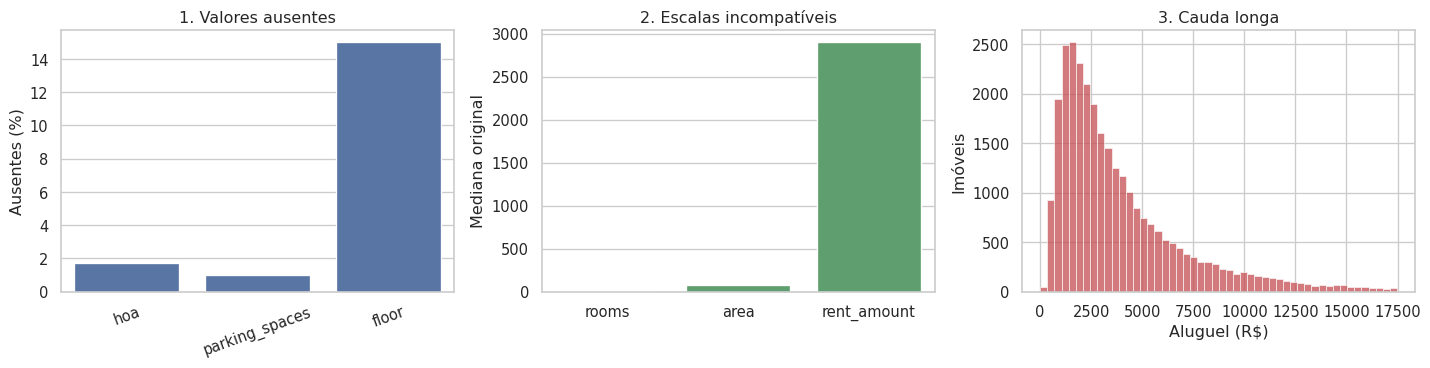

In [5]:
# Figura-resumo com os três problemas da aula
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(
    x=missing.index,
    y=missing.values,
    ax=axes[0],
    color="#4C72B0",
)
axes[0].set(
    title="1. Valores ausentes",
    ylabel="Ausentes (%)",
    xlabel="",
)
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    x=scales.index,
    y=scales.values,
    ax=axes[1],
    color="#55A868",
)
axes[1].set(
    title="2. Escalas incompatíveis",
    ylabel="Mediana original",
    xlabel="",
)

sns.histplot(
    imoveis["rent_amount"],
    bins=50,
    binrange=(0, limit),
    ax=axes[2],
    color="#C44E52",
)
axes[2].set(
    title="3. Cauda longa",
    xlabel="Aluguel (R$)",
    ylabel="Imóveis",
)

plt.tight_layout()
plt.show()

A leitura da figura revela os três problemas:

1.  **Valores ausentes.** `hoa` e `parking_spaces` têm poucas lacunas
    (cerca de 2% e 1%), enquanto `floor` chega a 15%. Uma diferença tão
    grande sugere que a ausência em `floor` tem uma causa própria,
    investigada na seção 2.
2.  **Escalas incompatíveis.** O imóvel típico tem 2 quartos, cerca de
    76 m² e aluguel de R\$ 2.900. As três medianas estão separadas por
    ordens de grandeza, e o aluguel domina o painel apenas por causa da
    unidade.
3.  **Cauda longa.** Três quartos dos aluguéis ficam abaixo de cerca de
    R\$ 5.100, mas a cauda se estende muito à direita. O maior aluguel
    chega a quase R\$ 38 mil, bem além do recorte do gráfico. A média
    (cerca de R\$ 4.000) fica acima da mediana, o mesmo padrão de
    assimetria positiva visto na Aula 5.

A ordem das seções acompanha uma sequência comum de pré-processamento.
Primeiro, investigamos as lacunas e decidimos quais delas representam
informação perdida. Muitos estimadores não aceitam valores ausentes em
sua entrada, mas esse não é o único motivo para tratá-los. Também
precisamos evitar que procedimentos diferentes descartem subconjuntos
distintos da base. Depois, examinamos separadamente a escala numérica e
a forma das distribuições.

# 2. Ausência estrutural

Ao encontrar uma coluna com lacunas, é tentador preenchê-las
imediatamente. Antes de escolher uma técnica, precisamos investigar
**por que** o valor está ausente. Nem toda célula vazia representa erro
de coleta ou perda de informação.

Na base de imóveis, `floor` e `total_floors` estão ausentes nas casas.
Não houve falha de cadastro. Esses atributos descrevem a posição de uma
unidade em um edifício e, portanto, não se aplicam a casas. Esse tipo de
lacuna é chamado de **ausência estrutural**, pois decorre da definição
da variável para determinado tipo de observação. Imputar um número
produziria um valor sem referente real.

In [6]:
# Número de imóveis e proporção sem andar, por tipo
(
    imoveis
    .groupby("property_type")
    .agg(
        imoveis=("property_type", "size"),
        proporcao_sem_andar=(
            "floor",
            lambda x: (
                x
                .isna()
                .mean()
            ),
        ),
    )
)

> **Important**
>
> Quando a ausência decorre de uma característica conhecida da
> observação, registre essa característica e **não impute** um valor
> numérico. Aqui, `property_type` torna explícita a informação que antes
> estava codificada apenas pela lacuna.

Depois de separar o caso estrutural, restam lacunas que podem
representar informação perdida, como um aluguel não informado ou um
número de vagas não registrado. Para esses casos, a imputação é uma
alternativa possível. A escolha ainda depende do mecanismo que produziu
a ausência e da quantidade de dados faltantes.

# 3. Imputação: o impacto das alternativas

Imputar consiste em substituir um valor ausente por uma estimativa
calculada a partir das informações disponíveis. Há estratégias simples,
como usar uma medida de posição da própria coluna, e métodos
multivariados, que estimam cada lacuna a partir de outras variáveis.
Nesta aula, trabalharemos com estatísticas descritivas da Aula 5. Mesmo
simples, essas estratégias permitem observar efeitos importantes, como
concentração artificial de valores e redução da variabilidade.

Há uma dificuldade prática. Em uma lacuna real, o valor verdadeiro não
foi observado. Sem uma referência, não podemos calcular diretamente o
erro cometido pela imputação.

A saída é simular o problema:

1.  partir de registros completos,
2.  apagar alguns valores conhecidos,
3.  imputar e comparar com o valor original.

Primeiro, a função que apaga uma fração dos valores e a base completa,
que servirá de gabarito.

In [7]:
# Função de apagamento e base-gabarito
rng = np.random.default_rng(42)

def erase_at_random(values, share):
    return values.mask(rng.random(len(values)) < share)

imoveis_true = (
    imoveis
    .dropna(subset=["hoa", "parking_spaces"])
    .reset_index(drop=True)
)

Em seguida, criamos lacunas em três variáveis de tipos diferentes:
discreta, contínua e categórica.

In [8]:
# Apaga valores em três colunas de tipos diferentes
imoveis_missing = (
    imoveis_true
    .assign(
        rooms=lambda df: erase_at_random(df["rooms"], .10),
        rent_amount=lambda df: erase_at_random(df["rent_amount"], .15),
        furniture=lambda df: erase_at_random(df["furniture"], .08),
    )
)

Conferimos quantos valores foram apagados:

In [9]:
# Quantidade e proporção de valores apagados por coluna
(
    imoveis_missing[["rooms", "rent_amount", "furniture"]]
    .isna()
    .sum()
    .to_frame("ausentes")
    .assign(
        proporcao=lambda x: (
            x.ausentes / len(imoveis_missing)
        ).round(3)
    )
)

> **Por que o mecanismo de ausência importa?**
>
> O apagamento simulado é completamente aleatório, mecanismo conhecido
> como MCAR (*missing completely at random*). Isso significa que a
> probabilidade de apagar uma célula não depende de nenhuma variável
> observada nem do próprio valor apagado.
>
> Em dados reais, essa condição é forte e nem sempre plausível. A
> ausência pode estar associada ao próprio valor. Se imóveis caros
> anunciam “valor sob consulta” com maior frequência, por exemplo, a
> distribuição dos aluguéis observados deixa de representar a
> distribuição completa. Uma imputação baseada apenas nesses valores
> tende a subestimar os aluguéis omitidos.

## 3.1 Média, mediana e mediana agrupada

As estratégias mais simples substituem todas as lacunas por uma única
constante calculada com os valores observados da coluna. A média utiliza
toda a magnitude dos dados e, por isso, responde fortemente a valores
extremos. A mediana depende apenas da ordenação e é mais resistente a
caudas longas.

In [10]:
# Constantes para a imputação simples
rent_mean = (
    imoveis_missing.rent_amount
    .mean()
)

rent_median = (
    imoveis_missing.rent_amount
    .median()
)

A mediana por `tier` condiciona a estimativa ao padrão do imóvel. Cada
lacuna recebe a mediana calculada entre os anúncios do mesmo grupo. Se
um `tier` não tiver aluguéis observados, não será possível calcular sua
mediana. Nesse caso, a mediana global funciona como estratégia de
contingência.

In [11]:
# Imputação pela mediana de cada tier
rent_group = (
    imoveis_missing
    .groupby("tier")
    .rent_amount
    .transform(lambda x: x.fillna(x.median()))
    .fillna(rent_median)
)

Reunimos as versões do aluguel para compará-las lado a lado:

In [12]:
# Versões do aluguel a comparar
rent_versions = {
    "Original": imoveis_true.rent_amount,
    "Com lacunas": imoveis_missing.rent_amount,
    "Média": imoveis_missing.rent_amount.fillna(rent_mean),
    "Mediana": imoveis_missing.rent_amount.fillna(rent_median),
    "Mediana por tier": rent_group,
}

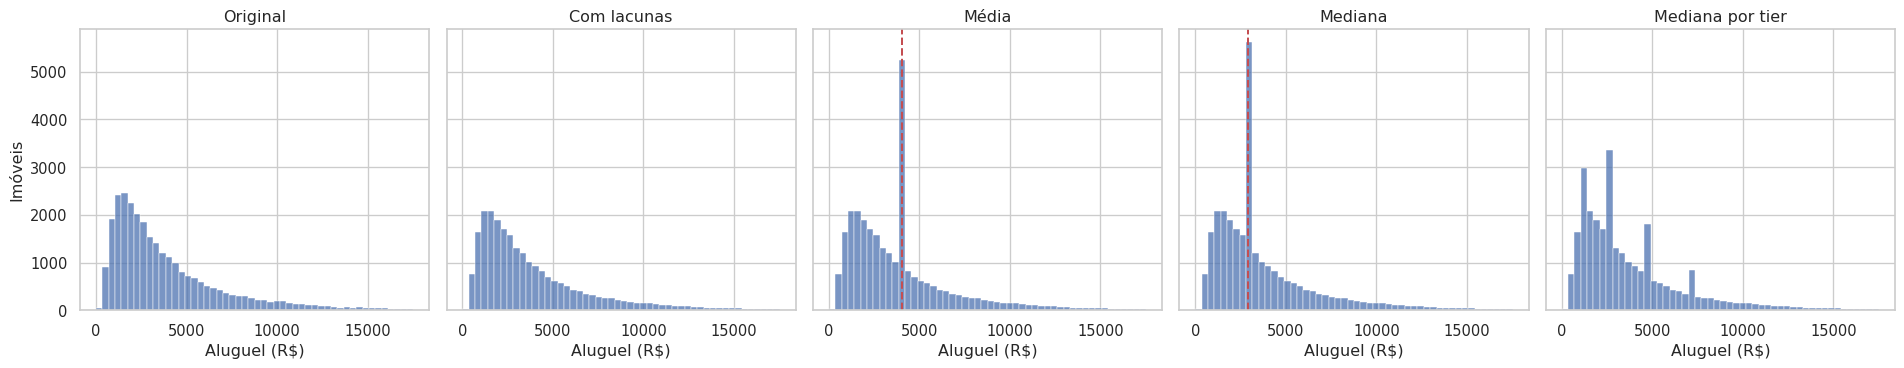

In [13]:
# Histograma de cada versão do aluguel
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

limit = imoveis_true.rent_amount.quantile(.99)

for ax, (label, values) in zip(axes, rent_versions.items()):
    sns.histplot(
        values.dropna(),
        bins=50,
        binrange=(0, limit),
        ax=ax,
        color="#4C72B0",
    )
    ax.set(
        title=label,
        xlabel="Aluguel (R$)",
        ylabel="Imóveis",
    )
    if label == "Média":
        ax.axvline(
            rent_mean,
            color="#C44E52",
            linestyle="--",
        )
    if label == "Mediana":
        ax.axvline(
            rent_median,
            color="#C44E52",
            linestyle="--",
        )

plt.tight_layout()
plt.show()

Dois efeitos aparecem nos histogramas:

-   **média e mediana** concentram todas as lacunas em um único valor,
    criando um pico artificial e reduzindo a dispersão,
-   **mediana por tier** distribui as lacunas entre vários valores, um
    por grupo.

### 3.1.1 Erro absoluto médio (MAE)

Os histogramas mostram como cada estratégia altera a **forma** da
distribuição, mas não dizem quão perto cada valor imputado ficou do
valor verdadeiro. Uma estratégia pode preservar bem o formato do
histograma e, ainda assim, errar muito imóvel a imóvel. Para avaliar a
**precisão** das estimativas, precisamos de uma métrica de erro. É aqui
que o gabarito se torna útil: como os valores foram apagados de
propósito, sabemos exatamente quanto cada lacuna deveria valer.

O erro de uma imputação é a diferença entre o valor verdadeiro $y_i$ e o
valor imputado $\hat{y}_i$. Essa diferença pode ser positiva ou
negativa, e uma média simples dos erros deixaria que subestimativas e
superestimativas se cancelassem, como a soma dos desvios em torno da
média na Aula 5. O **erro absoluto médio** (MAE, do inglês *mean
absolute error*) evita esse cancelamento ao tomar o valor absoluto de
cada erro antes de calcular a média:

$$
\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

Aqui, $n$ é o número de lacunas imputadas. O MAE é expresso na mesma
unidade da variável, o que facilita a interpretação: um MAE de R\$ 500
significa que, em média, a imputação errou o aluguel em R\$ 500, para
mais ou para menos.

Um exemplo pequeno ajuda a fixar o cálculo. Suponha três imóveis cujo
aluguel foi apagado e imputado com a mesma constante, R\$ 3.000:

| Imóvel | Verdadeiro ($y_i$) | Imputado ($\hat{y}_i$) | Erro absoluto |
|--------|--------------------|------------------------|---------------|
| A      | R\$ 2.000          | R\$ 3.000              | R\$ 1.000     |
| B      | R\$ 3.000          | R\$ 3.000              | R\$ 0         |
| C      | R\$ 10.000         | R\$ 3.000              | R\$ 7.000     |

O MAE é $(1.000 + 0 + 7.000)/3 \approx$ R\$ 2.666,67. Observe que um
único imóvel caro responde pela maior parte do erro.

Dois cuidados orientam o cálculo nesta seção:

-   **Apenas as posições imputadas entram na conta.** Nas posições
    observadas, o valor não foi alterado e o erro é zero por construção.
    Incluí-las reduziria artificialmente o MAE.
-   **A escolha da métrica favorece certas estratégias.** A mediana é o
    valor constante que minimiza a soma dos erros absolutos, enquanto a
    média minimiza a soma dos erros quadráticos. Por isso, entre as duas
    constantes, espera-se que a mediana apresente MAE menor, sobretudo
    em distribuições assimétricas como a do aluguel.

Primeiro, recuperamos no gabarito os valores verdadeiros das posições
apagadas:

In [14]:
# Posições apagadas e seus valores verdadeiros
rent_missing = imoveis_missing.rent_amount.isna()

truth = imoveis_true.loc[rent_missing, "rent_amount"]

In [15]:
# MAE de cada estratégia, apenas nas posições imputadas
(
    pd.Series(
        {
            "Média": (
                (truth - rent_mean)
                .abs()
                .mean()
            ),
            "Mediana": (
                (truth - rent_median)
                .abs()
                .mean()
            ),
            "Mediana por tier": (
                (truth - rent_group[rent_missing])
                .abs()
                .mean()
            ),
        },
        name="MAE (R$)",
    )
    .round(2)
    .to_frame()
)

Quanto menor o MAE, menor foi o erro médio das imputações neste
experimento. Como esperado, a mediana erra menos que a média. A mediana
por `tier` reduz ainda mais o erro, porque usa uma informação adicional,
o padrão do imóvel, para aproximar a estimativa do valor verdadeiro.

Essa comparação avalia a precisão pontual sob o mecanismo MCAR simulado.
Ela não garante que a mesma estratégia seja adequada quando o padrão de
ausência dos dados reais for diferente.

## 3.2 Moda e variáveis discretas

Para variáveis categóricas nominais, operações aritméticas como média e
mediana não têm interpretação válida. Uma alternativa simples é a moda,
isto é, a categoria observada com maior frequência.

Calculamos a categoria mais frequente de `furniture`:

In [16]:
# Categoria mais frequente de furniture
furniture_mode = (
    imoveis_missing.furniture
    .mode()
    .iloc[0]
)

furniture_mode

'not furnished'

Depois da imputação, todas as lacunas passam a contar como ocorrências
dessa categoria. A frequência da moda aumenta artificialmente, um efeito
que precisa ser considerado ao interpretar a distribuição resultante.

In [17]:
# Contagem das categorias antes e depois da imputação
(
    pd.concat(
        {
            "Antes": imoveis_missing.furniture.value_counts(dropna=False),
            "Depois da moda": (
                imoveis_missing.furniture
                .fillna(furniture_mode)
                .value_counts()
            ),
        },
        axis=1,
    )
    .fillna(0)
)

Em uma variável quantitativa discreta, como o número de quartos, a média
é matematicamente definida, mas pode produzir um valor incompatível com
o domínio da variável, como uma quantidade fracionária de quartos:

In [18]:
# Média, mediana e moda do número de quartos
(
    pd.Series(
        {
            "média": imoveis_missing.rooms.mean(),
            "mediana": imoveis_missing.rooms.median(),
            "moda": (
                imoveis_missing.rooms
                .mode()
                .iloc[0]
            ),
        },
        name="quartos",
    )
    .to_frame()
)

## 3.3 Resumo da imputação

| Situação                      | Escolha inicial       |
|-------------------------------|-----------------------|
| Contínua e simétrica          | Média                 |
| Assimétrica ou com extremos   | Mediana               |
| Categórica ou discreta        | Moda ou mediana       |
| Varia entre grupos conhecidos | Estatística por grupo |

> **Important**
>
> Antes de imputar, crie uma **coluna indicadora** para distinguir
> valores observados de estimados.

> **E se um grupo não tiver observações?**
>
> Sua mediana será `NaN`. Use a mediana global como segunda opção. Mesmo
> quando existe algum valor observado, grupos muito pequenos produzem
> estimativas com alta variabilidade amostral.

Encerrada a comparação entre estratégias de imputação, passamos a outro
problema. As colunas são expressas em unidades e ordens de grandeza
diferentes. As duas próximas seções distinguem o escalonamento, que
modifica a representação numérica, das transformações não lineares, que
também alteram a forma da distribuição.

# 4. Escalonamento: a régua muda, a forma não

O termo **normalização** não tem uso inteiramente uniforme na literatura
e nas bibliotecas. Nesta seção, tratamos de **escalonamento**, isto é,
transformações afins do tipo $x' = (x - c)/s$. O parâmetro $c$
representa um centro, como média, mediana ou mínimo, e $s$ representa
uma medida de escala, como desvio-padrão, IQR ou amplitude. Essa
operação preserva a ordenação das observações. Também multiplica todas
as distâncias por uma mesma constante positiva, de modo que o formato do
histograma, a assimetria e a curtose não se alteram. Muda a unidade em
que a variável é representada.

O objetivo do escalonamento é colocar variáveis numéricas em escalas
comparáveis. Algoritmos que calculam distâncias, como k-vizinhos mais
próximos e k-médias, são diretamente sensíveis às magnitudes dos
atributos. Métodos ajustados por gradiente e modelos com regularização
também podem ser afetados. Sem escalonamento, uma variável de maior
ordem de grandeza pode dominar o cálculo apenas por causa de sua
unidade. A padronização por z-score e o escalonamento Min-Max são duas
alternativas conhecidas. O scikit-learn ainda reserva o nome
`Normalizer` para a normalização de cada amostra por sua norma vetorial,
uma operação diferente das três estudadas aqui. Por isso, convém
verificar a definição exata da técnica em vez de confiar apenas no termo
empregado.

Na base de imóveis, área em m², aluguel em reais e número de quartos têm
ordens de grandeza muito diferentes. Uma diferença de um quarto pode
distinguir substancialmente dois imóveis. Uma diferença de R\$ 1 no
aluguel costuma ser desprezível. O escalonamento permite que essas
diferenças sejam comparadas em unidades relativas à distribuição de cada
atributo.

## 4.1 Três escaladores

Os três escaladores diferem na escolha do centro e da escala, e essa
escolha determina a sensibilidade a valores extremos.

| Técnica | Centro e escala | Sensibilidade a extremos | Indicação |
|------------------|------------------|------------------|------------------|
| `StandardScaler` | Média e desvio-padrão | Alta | Sem extremos importantes |
| `RobustScaler` | Mediana e IQR | Baixa | Com valores extremos |
| `MinMaxScaler` | Mínimo e máximo | Muito alta | Limites estáveis |

Aplicamos os três escaladores ao aluguel.

Os escaladores do scikit-learn recebem um `DataFrame` e devolvem uma
matriz. `.ravel()` converte essa matriz em vetor.

In [19]:
# Aplica os três escaladores ao aluguel
rent_frame = imoveis_true[["rent_amount"]]

scaled = {
    "Original": rent_frame.rent_amount.to_numpy(),
    "StandardScaler": (
        StandardScaler()
        .fit_transform(rent_frame)
        .ravel()
    ),
    "RobustScaler": (
        RobustScaler()
        .fit_transform(rent_frame)
        .ravel()
    ),
    "MinMaxScaler": (
        MinMaxScaler()
        .fit_transform(rent_frame)
        .ravel()
    ),
}

Observe o eixo horizontal e a assimetria de cada painel:

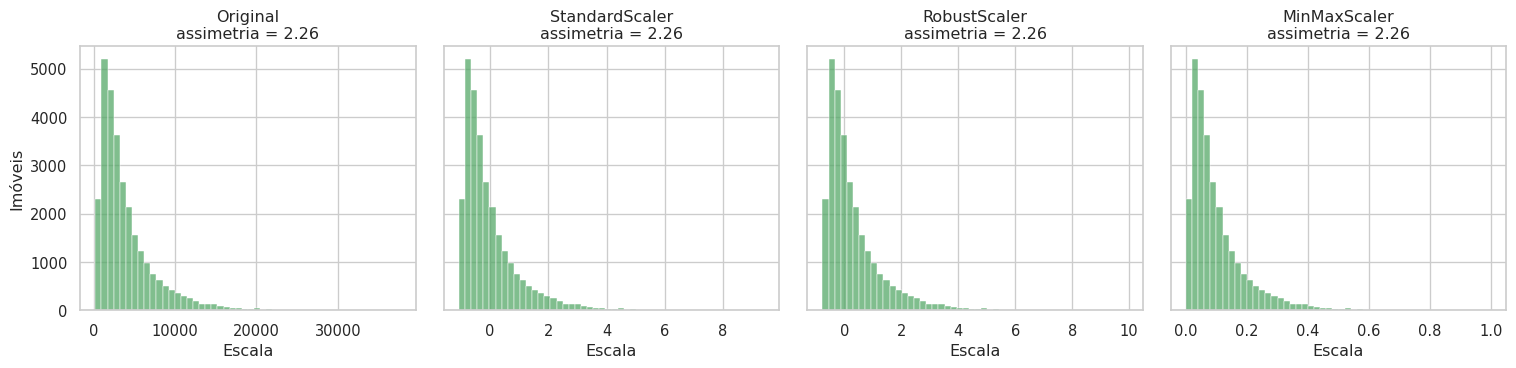

In [20]:
# Histograma do aluguel em cada escala
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, (label, values) in zip(axes, scaled.items()):
    sns.histplot(values, bins=50, ax=ax, color="#55A868")
    ax.set(
        title=f"{label}\nassimetria = {stats.skew(values):.2f}",
        xlabel="Escala",
        ylabel="Imóveis",
    )

plt.tight_layout()
plt.show()

Os quatro histogramas têm a mesma forma e a mesma assimetria. Apenas os
valores do eixo horizontal mudam, porque cada método define uma nova
origem e uma nova unidade de medida.

## 4.2 Sensibilidade a extremos

O Min-Max usa o mínimo e o máximo observados como referências. Um único
aluguel extremo aumenta a amplitude usada no denominador e comprime os
demais valores em uma faixa estreita próxima de zero.

Para ver o efeito, acrescentamos um aluguel fictício de R\$ 500 mil e o
descartamos depois do ajuste:

In [21]:
# Min-Max ajustado com um aluguel fictício de R$ 500 mil
with_extreme = pd.concat(
    [rent_frame, pd.DataFrame({"rent_amount": [500_000.]})],
    ignore_index=True,
)

minmax_extreme = (
    MinMaxScaler()
    .fit_transform(with_extreme)
    .ravel()[:-1]
)

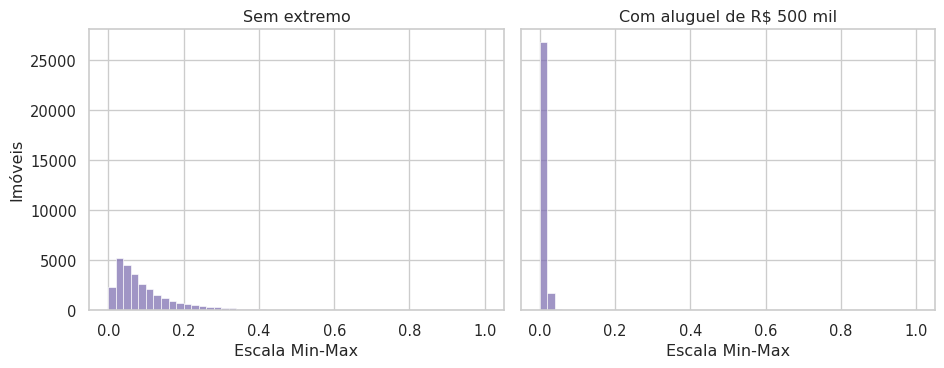

In [22]:
# Min-Max sem e com o valor extremo
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, values, title in zip(
    axes,
    [scaled["MinMaxScaler"], minmax_extreme],
    ["Sem extremo", "Com aluguel de R$ 500 mil"],
):
    sns.histplot(
        values,
        bins=50,
        binrange=(0, 1),
        ax=ax,
        color="#8172B2",
    )
    ax.set(
        title=title,
        xlabel="Escala Min-Max",
        ylabel="Imóveis",
    )

plt.tight_layout()
plt.show()

Com o extremo, quase todos os imóveis ficam concentrados no início da
escala. O `RobustScaler`, baseado na mediana e no IQR, é muito menos
sensível a esse efeito. O ponto extremo ainda permanece distante depois
da transformação, mas não determina o centro nem a escala usados para
representar a maioria das observações.

> **Important**
>
> **Escalonar muda a régua, não a forma.**

O escalonamento tornou as unidades comparáveis, mas o aluguel continua
com a mesma cauda longa observada na figura inicial. Poucos imóveis
muito caros ainda ocupam grande parte do eixo, enquanto a maioria dos
anúncios permanece concentrada à esquerda. Reduzir essa assimetria exige
uma transformação não linear.

# 5. Transformações: a forma muda

Esta seção trata do segundo sentido em que o termo **normalização**
aparece na literatura. Na seção 4, normalizar significava escalonar,
isto é, mudar a origem e a unidade de uma variável sem alterar sua
forma. Aqui, normalizar significa transformar a própria distribuição, em
geral para aproximá-la de uma forma mais simétrica e, em muitos casos,
mais próxima da distribuição normal, origem do nome. As duas operações
recebem o mesmo rótulo em textos e bibliotecas, mas produzem efeitos
diferentes sobre os dados. Por isso, ao encontrar o termo, convém
verificar qual dos dois sentidos está em jogo.

Nesta seção, usamos **transformação da distribuição** para designar a
aplicação de uma função não linear, como $\log(x)$ ou uma transformação
de potência. O objetivo pode ser reduzir a assimetria, estabilizar a
variância ou tornar uma relação multiplicativa mais próxima de uma
relação linear. Aproximar a variável de uma distribuição normal é uma
finalidade possível, mas não constitui uma exigência geral do
pré-processamento.

Ao contrário do escalonamento afim, uma função não linear comprime
regiões diferentes do eixo em intensidades diferentes. O logaritmo reduz
mais as distâncias entre valores altos do que entre valores baixos. Na
escala logarítmica, a distância entre R\$ 1.000 e R\$ 2.000 é igual à
distância entre R\$ 10.000 e R\$ 20.000, pois os dois pares representam
a mesma razão. A ordenação é preservada, mas as diferenças absolutas e
as razões entre distâncias mudam. Com isso, também podem mudar a
assimetria, a curtose e a influência de observações extremas.

Esse tipo de transformação é útil quando a escala original produz forte
heterogeneidade de variância, quando relações multiplicativas descrevem
melhor o fenômeno ou quando uma cauda longa exerce influência excessiva
sobre o ajuste. O custo aparece na interpretação. Um coeficiente ou uma
média calculados na escala transformada já não estão expressos
diretamente em reais. Transformações como Box-Cox e Yeo-Johnson ampliam
as possibilidades do logaritmo ao estimar, a partir dos dados, um
parâmetro de potência associado à aproximação da normalidade.

Quando o problema é a cauda longa, mudar a régua não basta. É preciso
mudar a **forma** da distribuição. A escolha da transformação depende
dos valores que a variável aceita: algumas exigem valores estritamente
positivos, outras aceitam zero ou até negativos.

## 5.1 Aluguel positivo: log e Box-Cox

Nesta base, todos os aluguéis são estritamente positivos, condição
necessária para aplicar `log` e Box-Cox. Começamos pelo logaritmo,
frequentemente adequado a valores monetários com variação
multiplicativa, e o comparamos com Box-Cox, que estima um parâmetro de
potência a partir dos dados.

`stats.boxcox` devolve os valores transformados e o λ estimado.

In [23]:
# Aluguel original, em log e em Box-Cox
rent = imoveis_true.rent_amount

boxcox_rent, boxcox_lambda = stats.boxcox(rent)

rent_transformed = {
    "Original": rent,
    "log": np.log(rent),
    f"Box-Cox (λ={boxcox_lambda:.2f})": boxcox_rent,
}

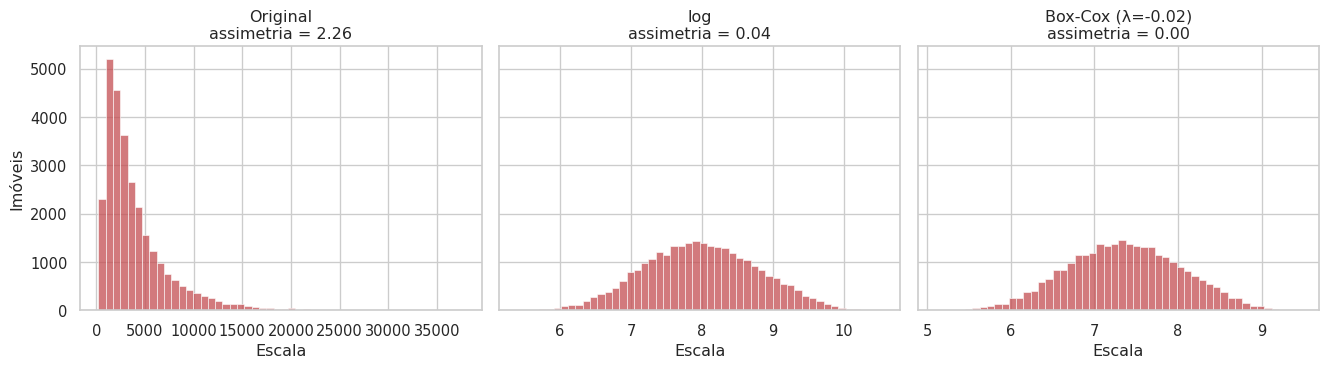

In [24]:
# Histogramas das transformações do aluguel
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (label, values) in zip(axes, rent_transformed.items()):
    sns.histplot(values, bins=50, ax=ax, color="#C44E52")
    ax.set(
        title=f"{label}\nassimetria = {stats.skew(values):.2f}",
        xlabel="Escala",
        ylabel="Imóveis",
    )

plt.tight_layout()
plt.show()

Box-Cox estima o parâmetro λ por máxima verossimilhança sob a hipótese
de que os valores transformados se aproximam de uma distribuição normal.
Quando λ = 0, sua definição corresponde ao logaritmo natural.

O valor de λ próximo de zero mostra que, dentro da família Box-Cox, a
transformação estimada é muito semelhante ao logaritmo. Isso sustenta o
uso de `log` para o aluguel desta base.

Nem toda variável, porém, é estritamente positiva. Quando há zeros, o
logaritmo deixa de ser definido, e é preciso recorrer a variantes.

## 5.2 Distância com zeros: `log1p` e Yeo-Johnson

A distância ao transporte pode ser igual a zero para imóveis localizados
junto a uma estação. Como `log` e Box-Cox exigem valores estritamente
positivos, não podem ser aplicados diretamente. Duas alternativas são
`log1p`, que calcula $\log(1+x)$, e Yeo-Johnson, uma transformação de
potência definida também para zero e valores negativos.

Com `standardize=False`, o `PowerTransformer` apenas transforma, sem
escalonar.

In [25]:
# Distância original, em log1p e em Yeo-Johnson
transit = imoveis_true.transit_distance_min

pt = PowerTransformer(method="yeo-johnson", standardize=False)

transit_yj = (
    pt
    .fit_transform(imoveis_true[["transit_distance_min"]])
    .ravel()
)

transformed = {
    "Original": transit,
    "log1p": np.log1p(transit),
    f"Yeo-Johnson (λ={pt.lambdas_[0]:.2f})": transit_yj,
}

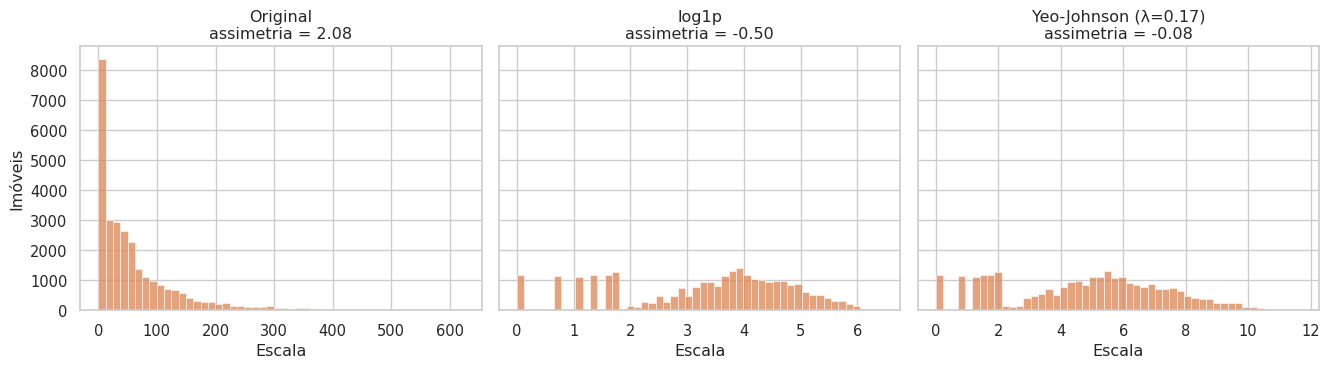

In [26]:
# Histogramas das transformações da distância
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (label, values) in zip(axes, transformed.items()):
    sns.histplot(values, bins=50, ax=ax, color="#DD8452")
    ax.set(
        title=f"{label}\nassimetria = {stats.skew(values):.2f}",
        xlabel="Escala",
        ylabel="Imóveis",
    )

plt.tight_layout()
plt.show()

Compare as assimetrias:

-   `log1p` aceita zeros, mas aqui comprime a cauda direita além do
    necessário,
-   Yeo-Johnson aceita qualquer sinal e estima uma transformação mais
    branda.

## 5.3 Resumo das transformações

| Técnica     | Valores aceitos  | Interpretação                      |
|-------------|------------------|------------------------------------|
| `log`       | Positivos        | Boa: diferenças representam razões |
| `log1p`     | Zero e positivos | Boa, com inversa `expm1`           |
| Box-Cox     | Positivos        | Menos direta                       |
| Yeo-Johnson | Qualquer sinal   | Menos direta                       |

> **Fórmula e interpretação**
>
> A transformação de Box-Cox é dada por:
>
> $$
> x^{(\lambda)} =
> \begin{cases}
> \dfrac{x^\lambda - 1}{\lambda}, & \lambda \ne 0 \\[6pt]
> \log(x), & \lambda = 0
> \end{cases}
> $$
>
> Para voltar à unidade original:
>
> -   após `log`, use `np.exp`,
> -   após `log1p`, use `np.expm1`.

> **Important**
>
> **Transformar muda a forma.** A redução da assimetria deve ser
> avaliada junto com a perda de interpretação direta na unidade
> original.

Até aqui, cada técnica foi estudada isoladamente, em uma ou duas
variáveis e sobre a base de gabarito. Na prática, porém, as decisões são
aplicadas em conjunto e na ordem certa, sobre a base original, com suas
lacunas reais.

# 6. Aplicação e comparação final

Esta seção reúne as decisões anteriores em um único fluxo aplicado à
base completa. A ordem das operações importa. As colunas indicadoras
precisam ser criadas antes da imputação, enquanto as posições
originalmente ausentes ainda são identificáveis. A imputação precede as
transformações para que as medianas sejam calculadas e interpretadas na
unidade original.

Aplicamos as decisões em três etapas.

## 6.1 Registrar as lacunas

As colunas indicadoras são criadas **antes** da imputação. Depois dela,
o rastro se perderia.

In [27]:
# Colunas indicadoras das lacunas originais
imoveis_processed = (
    imoveis
    .assign(
        hoa_missing=lambda x: x.hoa.isna(),
        parking_spaces_missing=lambda x: x.parking_spaces.isna(),
    )
)

## 6.2 Imputar pela mediana do grupo

Os grupos combinam tipo de imóvel e `tier`. Grupos sem observações
recebem a mediana global.

In [28]:
# Imputa hoa e vagas pela mediana de cada grupo
groups = ["property_type", "tier"]

imoveis_processed = (
    imoveis_processed
    .assign(
        hoa=lambda x: (
            x
            .groupby(groups)
            .hoa
            .transform(lambda s: s.fillna(s.median()))
            .fillna(imoveis.hoa.median())
        ),
        parking_spaces=lambda x: (
            x
            .groupby(groups)
            .parking_spaces
            .transform(lambda s: s.fillna(s.median()))
            .fillna(imoveis.parking_spaces.median())
        ),
    )
)

Conferimos que não restaram lacunas e quantos valores foram estimados:

In [29]:
# Lacunas restantes e valores estimados
(
    imoveis_processed
    .agg(
        {
            "hoa": lambda s: s.isna().sum(),
            "parking_spaces": lambda s: s.isna().sum(),
            "hoa_missing": "sum",
            "parking_spaces_missing": "sum",
        }
    )
)

hoa                         0
parking_spaces              0
hoa_missing               505
parking_spaces_missing    297
dtype: int64

## 6.3 Reduzir as caudas

Seguimos o resumo da seção 5.3:

-   área e valores monetários são positivos e recebem `log`,
-   a distância, que pode ser zero, recebe Yeo-Johnson.

In [30]:
# Log nas variáveis positivas e Yeo-Johnson na distância
imoveis_processed = (
    imoveis_processed
    .assign(
        area=lambda x: np.log(x.area),
        rent_amount=lambda x: np.log(x.rent_amount),
        property_tax=lambda x: np.log(x.property_tax),
        total=lambda x: np.log(x.total),
        transit_distance_min=lambda x: stats.yeojohnson(
            x.transit_distance_min
        )[0],
    )
)

## 6.4 Antes e depois

Comparamos as distribuições das cinco variáveis transformadas:

In [31]:
# Variáveis comparadas e seus rótulos nos gráficos
columns = [
    "area",
    "rent_amount",
    "property_tax",
    "total",
    "transit_distance_min",
]

labels = ["Área", "Aluguel", "IPTU", "Total", "Distância"]

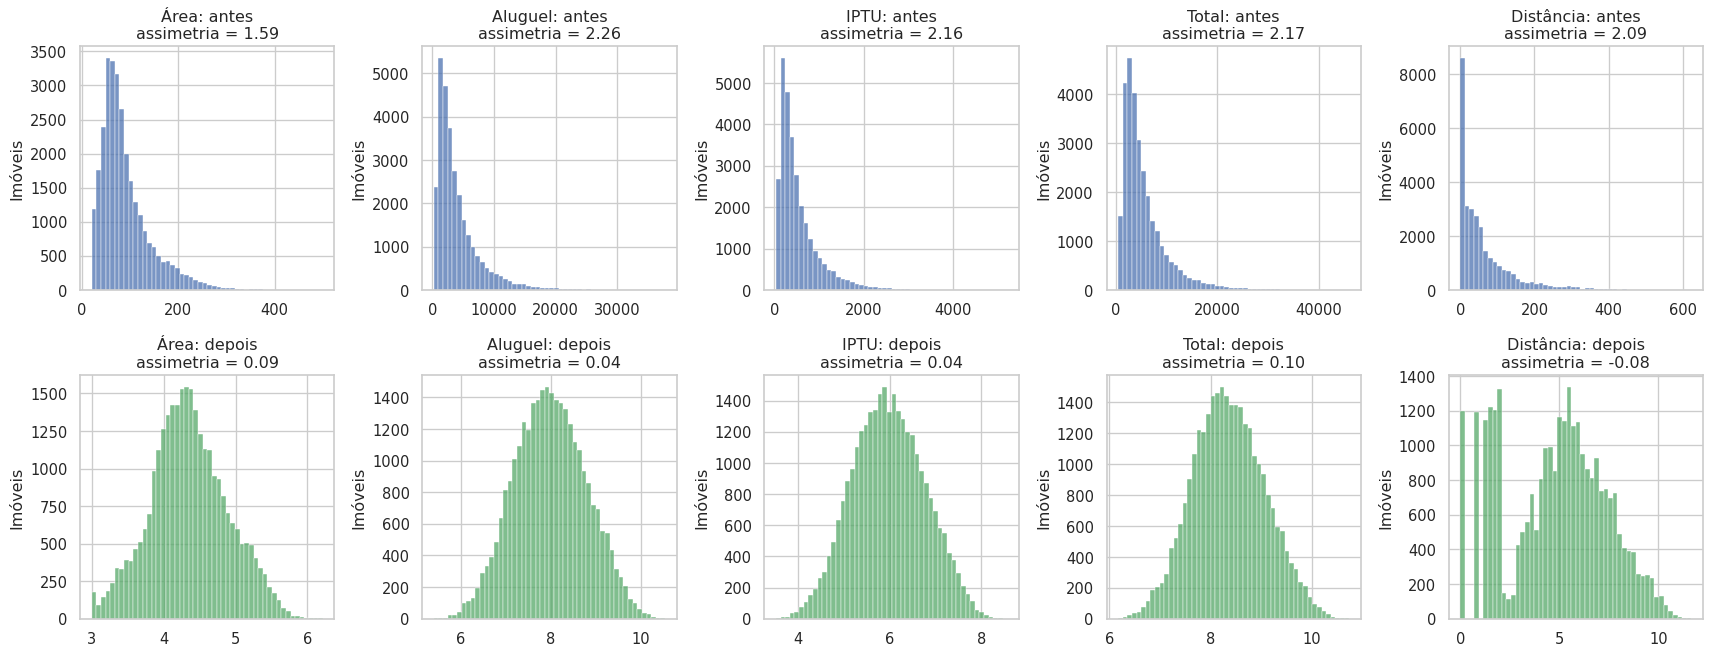

In [32]:
# Distribuições antes (linha de cima) e depois (linha de baixo)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for col, label, ax1, ax2 in zip(columns, labels, axes[0], axes[1]):
    before, after = imoveis[col], imoveis_processed[col]
    sns.histplot(before, bins=50, ax=ax1, color="#4C72B0")
    ax1.set(
        title=f"{label}: antes\nassimetria = {stats.skew(before):.2f}",
        xlabel="",
        ylabel="Imóveis",
    )
    sns.histplot(after, bins=50, ax=ax2, color="#55A868")
    ax2.set(
        title=f"{label}: depois\nassimetria = {stats.skew(after):.2f}",
        xlabel="",
        ylabel="Imóveis",
    )

plt.tight_layout()
plt.show()

Na linha inferior, as distribuições apresentam menor assimetria, e os
valores extremos ocupam uma parcela menor do eixo. Isso não significa
que os extremos foram removidos. Suas distâncias em relação ao centro
foram comprimidas pela transformação.

> **Evite vazamento**
>
> Em um projeto de modelagem, os dados são divididos em treino e teste.
>
> Medianas, parâmetros λ e parâmetros dos escaladores devem ser
> estimados **apenas no conjunto de treino**. Em seguida, os mesmos
> valores estimados são aplicados ao conjunto de teste. Ajustá-los antes
> da separação permite que informações do teste influenciem o
> pré-processamento e produz vazamento de dados.

> **Extensão opcional: ydata-profiling**
>
> O relatório automático é útil para auditoria, mas não é necessário
> para o argumento visual da aula.
>
> ``` python
> # Relatório comparativo antes e depois do pré-processamento
> from ydata_profiling import ProfileReport, compare
>
> before = ProfileReport(
>     imoveis,
>     minimal=True,
> )
>
> after = ProfileReport(
>     imoveis_processed,
>     minimal=True,
> )
>
> (
>     compare([before, after])
>     .to_file(
>         "imoveis-sao-paulo/reports/comparacao_pre_processamento.html"
>     )
> )
> ```

# 7. Guia rápido

A tabela reúne as decisões discutidas no roteiro. Ela oferece critérios
iniciais, não regras automáticas. A escolha final depende do mecanismo
de ausência, da distribuição observada, do modelo empregado e do
objetivo da análise.

| Problema                         | Técnica                |
|----------------------------------|------------------------|
| Ausência estrutural              | Não imputar, registrar |
| Contínua simétrica               | Média                  |
| Assimétrica ou com extremos      | Mediana                |
| Categórica ou discreta           | Moda ou mediana        |
| Varia entre grupos               | Mediana por grupo      |
| Escalas diferentes, sem extremos | Z-score                |
| Escalas diferentes, com extremos | RobustScaler           |
| Limites estáveis                 | Min-Max                |
| Cauda positiva                   | Log ou Box-Cox         |
| Cauda com zeros                  | log1p ou Yeo-Johnson   |

## Síntese

Três classes de tratamento foram aplicadas à base de imóveis:

1.  **Imputação.** Nem toda ausência corresponde a um valor que deveria
    existir. Quando a imputação for apropriada, a estratégia deve
    considerar o tipo da variável, sua distribuição e as informações
    disponíveis em outros atributos. Uma coluna indicadora preserva o
    registro das posições estimadas.
2.  **Escalonamento.** Uma transformação afim altera a origem e a
    unidade da variável sem modificar a forma de sua distribuição. A
    presença de valores extremos influencia a escolha entre parâmetros
    convencionais, como média e desvio-padrão, e parâmetros robustos,
    como mediana e IQR.
3.  **Transformação.** Uma função não linear modifica as distâncias
    entre observações e pode reduzir a assimetria. Essa mudança pode
    favorecer a modelagem, mas exige cuidado ao interpretar e comunicar
    resultados na escala original.

# Perguntas para consolidar

## Pergunta 1: imputar sempre melhora a análise?

A seção 2 mostrou lacunas que não deveriam ser preenchidas. Em que
situação uma estratégia com MAE baixo no experimento controlado ainda
pode piorar a análise quando aplicada à base real?

> **Como pensar sobre isso**
>
> O MAE mede a distância entre valores imputados e valores verdadeiros
> nas posições apagadas artificialmente. Ele avalia o desempenho sob o
> mecanismo de ausência usado na simulação. Não demonstra que a variável
> seja aplicável a todas as observações nem que o mesmo padrão de
> ausência exista na base real.
>
> No caso do andar de uma casa, não existe valor verdadeiro a estimar,
> pois o atributo não se aplica à observação. O MAE nem sequer é uma
> métrica conceitualmente válida para esse caso. Em lacunas não
> estruturais, uma estratégia também pode apresentar baixo MAE sob MCAR
> e introduzir viés quando a ausência real depende do valor omitido.
> Imputações por constantes ainda reduzem a variabilidade observada e
> criam concentrações artificiais. Sem uma coluna indicadora, deixa de
> ser possível separar o que foi observado do que foi estimado.

## Pergunta 2: por que o `StandardScaler` não resolveu a assimetria?

Na seção 4.1, os três escaladores produziram a mesma assimetria do
aluguel original. Por que isso acontece?

> **Como pensar sobre isso**
>
> Os escaladores estudados aplicam uma transformação afim. Eles subtraem
> um centro e dividem por uma constante positiva. A operação desloca o
> eixo e multiplica todas as distâncias pela mesma constante.
>
> Como todas as distâncias são multiplicadas pelo mesmo fator, os
> momentos padronizados que definem assimetria e curtose permanecem
> iguais. Para mudar a forma, precisamos de uma transformação não
> linear, como `log` ou Box-Cox.

## Pergunta 3: qual escala você apresentaria ao gestor?

O `log` reduziu fortemente a assimetria do aluguel. Você apresentaria ao
gestor um gráfico do aluguel em escala log?

> **Como pensar sobre isso**
>
> Depende do objetivo e do público. Para determinados modelos
> estatísticos, a escala transformada pode produzir relações mais
> lineares, variância mais estável ou menor influência da cauda.
>
> Para comunicação, a unidade original em reais costuma ser mais direta.
> Uma possibilidade é ajustar o modelo na escala logarítmica e converter
> previsões com `np.exp` antes de apresentá-las. Essa conversão exige
> atenção. A exponencial de uma previsão média na escala log não
> coincide, em geral, com a média condicional na escala original sem uma
> correção de retransformação.

# Para casa

1.  Compare o MAE da média e da mediana para `rooms` e relacione o
    resultado à assimetria e ao caráter discreto da variável.
2.  Impute o aluguel por `tier` e `zona`. Depois, use o bairro como
    grupo e discuta o efeito de grupos pequenos.
3.  Entre apartamentos, compare `log1p`, Box-Cox e Yeo-Johnson para
    `hoa`. Qual produz menor assimetria? Qual você apresentaria a um
    gestor?
4.  Antes de considerar o notebook pronto, use Restart Kernel and Run
    All.

> Escalonar muda a régua. Transformar muda a forma. Imputar muda os
> dados e deve deixar rastro.